In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score
import sys, os

sys.path.insert(0, os.path.abspath('.'))

from threshold_validation import validate_thresholds, validate_by_id, print_validation_report
from match_vectors import compute_match, compute_match_by_id, rank_students_for_job, SKILL_COLS
from explainability import generate_explanation, print_full_report

print('imports done')

imports done


## Load the data

In [3]:
students = pd.read_csv('data/students.csv')
jobs = pd.read_csv('data/jobs.csv')

print('students:', len(students))
print('jobs:', len(jobs))
students.head()

students: 15
jobs: 8


,student_id,name,python,ml,sql,dsa,statistics,deep_learning
0,1,Aditya Sharma,75,70,60,55,65,50
1,2,Priya Nair,90,85,80,75,88,78
2,3,Rohan Mehta,40,35,50,60,45,30
3,4,Sneha Iyer,55,60,45,40,50,35
4,5,Karan Patel,80,78,72,68,74,65


In [4]:
jobs

,job_id,company,role,python,ml,sql,dsa,statistics,deep_learning
0,101,DataCorp,Data Scientist,70,65,50,0,60,0
1,102,TechFusion,ML Engineer,85,80,70,60,75,70
2,103,AnalyticsPro,Data Analyst,50,40,75,0,65,0
3,104,DeepMind Labs,AI Researcher,90,95,60,80,85,90
4,105,StartupXYZ,Junior Data Scientist,50,45,40,0,40,0
5,106,FinanceHub,Quantitative Analyst,65,55,80,0,90,0
6,107,RetailAI,ML Ops Engineer,75,70,55,70,50,60
7,108,HealthTech,Medical Data Analyst,55,50,70,0,75,0


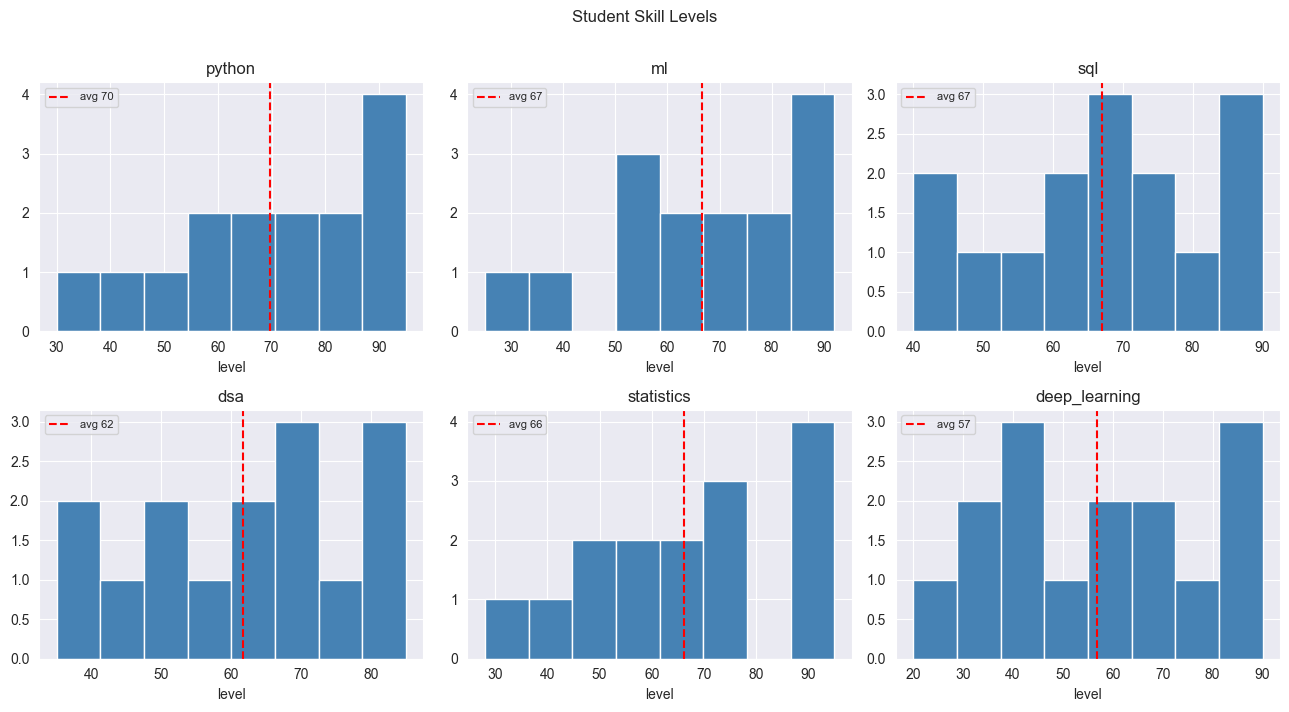

In [5]:
# quick look at skill distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, skill in enumerate(SKILL_COLS):
    axes[i].hist(students[skill], bins=8, color='steelblue', edgecolor='white')
    axes[i].set_title(skill)
    axes[i].set_xlabel('level')
    mean_val = students[skill].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'avg {mean_val:.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Student Skill Levels', y=1.01)
plt.tight_layout()
plt.savefig('skill_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Threshold Validation

In [6]:
# basic test - student 1 vs job 101
r = validate_by_id(student_id=1, job_id=101)
print_validation_report(r)


Student : Aditya Sharma
Role    : Data Scientist @ DataCorp
----------------------------------------
  ✓ python           student=75  required=70  gap=+5
  ✓ ml               student=70  required=65  gap=+5
  ✓ sql              student=60  required=50  gap=+10
  ✓ statistics       student=65  required=60  gap=+5
----------------------------------------
Result: ELIGIBLE ✅
Passed: python, ml, sql, statistics


In [7]:
# student 3 has low scores, should fail for job 102
r = validate_by_id(student_id=3, job_id=102)
print_validation_report(r)


Student : Rohan Mehta
Role    : ML Engineer @ TechFusion
----------------------------------------
  ✗ python           student=40  required=85  gap=-45
  ✗ ml               student=35  required=80  gap=-45
  ✗ sql              student=50  required=70  gap=-20
  ✓ dsa              student=60  required=60  gap=+0
  ✗ statistics       student=45  required=75  gap=-30
  ✗ deep_learning    student=30  required=70  gap=-40
----------------------------------------
Result: NOT ELIGIBLE ❌
Failed: python, ml, sql, statistics, deep_learning


In [8]:
# run threshold check for every student-job combo
pairs = []
for _, s in students.iterrows():
    for _, j in jobs.iterrows():
        res = validate_thresholds(s[SKILL_COLS].to_dict(), j[SKILL_COLS].to_dict())
        pairs.append({
            'student_id': int(s['student_id']),
            'name': s['name'],
            'job_id': int(j['job_id']),
            'company': j['company'],
            'eligible': res['eligible'],
            'num_failed': len(res['failed_skills'])
        })

pairs_df = pd.DataFrame(pairs)
print(f"Total pairs: {len(pairs_df)}")
print(f"Eligible: {pairs_df['eligible'].sum()} ({pairs_df['eligible'].mean()*100:.1f}%)")
pairs_df.head(10)

Total pairs: 120
Eligible: 44 (36.7%)


,student_id,name,job_id,company,eligible,num_failed
0,1,Aditya Sharma,101,DataCorp,True,0
1,1,Aditya Sharma,102,TechFusion,False,6
2,1,Aditya Sharma,103,AnalyticsPro,False,1
3,1,Aditya Sharma,104,DeepMind Labs,False,5
4,1,Aditya Sharma,105,StartupXYZ,True,0
5,1,Aditya Sharma,106,FinanceHub,False,2
6,1,Aditya Sharma,107,RetailAI,False,2
7,1,Aditya Sharma,108,HealthTech,False,2
8,2,Priya Nair,101,DataCorp,True,0
9,2,Priya Nair,102,TechFusion,True,0


## Match Vectors

In [9]:
r = compute_match_by_id(student_id=1, job_id=101)
print('student vector:', r['student_vector'])
print('job vector    :', r['job_vector'])
print('cosine sim    :', r['cosine_similarity'])
print('euclidean     :', r['euclidean_score'])
print('weighted      :', r['weighted_score'])
print('final score   :', r['match_score'])

student vector: [75.0, 70.0, 60.0, 55.0, 65.0, 50.0]
job vector    : [70.0, 65.0, 50.0, 0.0, 60.0, 0.0]
cosine sim    : 87.59
euclidean     : 69.18
weighted      : 100.0
final score   : 88.87


In [10]:
# rank all students for job 101
ranking = rank_students_for_job(101)
ranking

,student_id,name,match_score,cosine,weighted
0,1,Aditya Sharma,88.87,87.59,100.00
1,12,Nisha Joshi,87.34,85.50,100.00
2,6,Divya Rao,86.41,86.66,93.88
3,5,Karan Patel,85.83,84.77,100.00
4,14,Kavya Menon,85.82,87.04,91.02
5,4,Sneha Iyer,85.31,89.12,85.71
6,9,Manish Kumar,85.01,81.65,100.00
7,13,Siddharth Bose,84.98,84.32,100.00
8,2,Priya Nair,83.99,84.29,100.00
9,10,Pooja Gupta,82.57,83.56,100.00


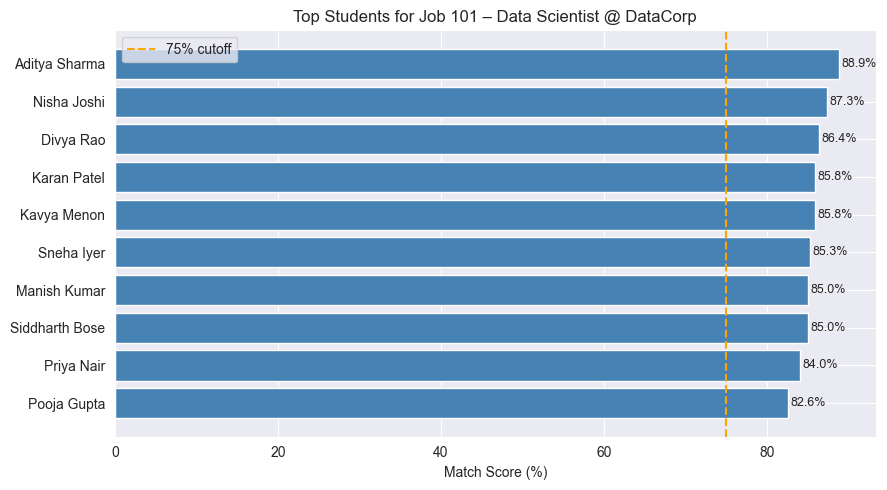

In [11]:
top10 = ranking.head(10)

plt.figure(figsize=(9, 5))
bars = plt.barh(top10['name'][::-1], top10['match_score'][::-1], color='steelblue')
plt.xlabel('Match Score (%)')
plt.title('Top Students for Job 101 – Data Scientist @ DataCorp')
plt.axvline(75, color='orange', linestyle='--', label='75% cutoff')
plt.legend()
for bar, score in zip(bars, top10['match_score'][::-1]):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('ranking_job101.png', dpi=100, bbox_inches='tight')
plt.show()

## Full Match Report (Explainability)

In [12]:
s = students[students['student_id'] == 1].iloc[0]
j = jobs[jobs['job_id'] == 101].iloc[0]

result = generate_explanation(
    s[SKILL_COLS].to_dict(),
    j[SKILL_COLS].to_dict(),
    student_name=s['name'],
    job_role=f"{j['role']} @ {j['company']}"
)
print_full_report(result, student_name=s['name'], job_role=f"{j['role']} @ {j['company']}")


  PlaceMux Match Report
  Student : Aditya Sharma
  Role    : Data Scientist @ DataCorp
--------------------------------------------------
  Threshold Check:
    ✓  python           student=75  required=70  gap=+5
    ✓  ml               student=70  required=65  gap=+5
    ✓  sql              student=60  required=50  gap=+10
    ✓  statistics       student=65  required=60  gap=+5
--------------------------------------------------
  Result         : ELIGIBLE ✅
  Match Score    : 88.9%
  Cosine Sim.    : 87.6%
  Weighted Score : 100.0%
--------------------------------------------------
  Why: Aditya Sharma clears all required thresholds for Data Scientist @ DataCorp (python, ml, sql and statistics). Strong in sql (well above what's needed). Overall skill profile is a solid match (score: 88.9%, cosine: 87.6%).


In [13]:
# borderline case
s = students[students['student_id'] == 4].iloc[0]
j = jobs[jobs['job_id'] == 101].iloc[0]

result = generate_explanation(
    s[SKILL_COLS].to_dict(),
    j[SKILL_COLS].to_dict(),
    student_name=s['name'],
    job_role=f"{j['role']} @ {j['company']}"
)
print_full_report(result, student_name=s['name'], job_role=f"{j['role']} @ {j['company']}")


  PlaceMux Match Report
  Student : Sneha Iyer
  Role    : Data Scientist @ DataCorp
--------------------------------------------------
  Threshold Check:
    ✗  python           student=55  required=70  gap=-15
    ✗  ml               student=60  required=65  gap=-5
    ✗  sql              student=45  required=50  gap=-5
    ✗  statistics       student=50  required=60  gap=-10
--------------------------------------------------
  Result         : NOT ELIGIBLE ❌
  Match Score    : 85.3%
  Cosine Sim.    : 89.1%
  Weighted Score : 85.7%
--------------------------------------------------
  Why: Sneha Iyer doesn't qualify for Data Scientist @ DataCorp — minimum threshold not met for: python, ml, sql, statistics. Gaps found in: python (needs 15 more points), ml (needs 5 more points), sql (needs 5 more points), statistics (needs 10 more points). Overall skill profile is a solid match (score: 85.3%, cosine: 89.1%).


## Metrics

Using threshold validation as the ground truth label, and checking how well match_score >= 70 predicts eligibility.

In [14]:
eval_data = []
for _, s in students.iterrows():
    for _, j in jobs.iterrows():
        s_skills = s[SKILL_COLS].to_dict()
        j_reqs = j[SKILL_COLS].to_dict()

        t = validate_thresholds(s_skills, j_reqs)
        m = compute_match(s_skills, j_reqs)

        eval_data.append({
            'student_id': int(s['student_id']),
            'job_id': int(j['job_id']),
            'eligible_true': int(t['eligible']),
            'match_score': m['match_score']
        })

eval_df = pd.DataFrame(eval_data)

CUTOFF = 70.0
eval_df['eligible_pred'] = (eval_df['match_score'] >= CUTOFF).astype(int)

y_true = eval_df['eligible_true']
y_pred = eval_df['eligible_pred']

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
fpr = ((y_pred == 1) & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)

print(f'Score cutoff : {CUTOFF}%')
print(f'Precision    : {precision:.3f}')
print(f'Recall       : {recall:.3f}')
print(f'F1           : {f1:.3f}')
print(f'False +ve Rate: {fpr:.3f}')

Score cutoff : 70.0%
Precision    : 0.393
Recall       : 1.000
F1           : 0.564
False +ve Rate: 0.895


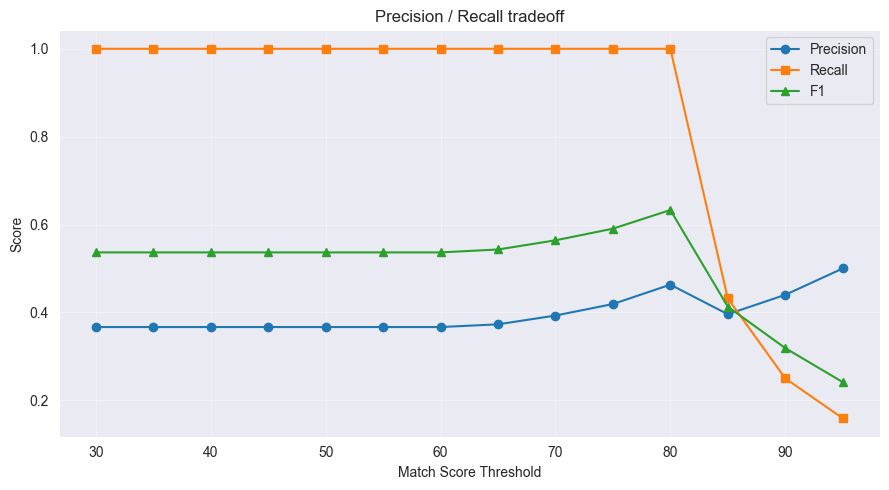

,threshold,precision,recall,f1
0,30,0.366667,1.000000,0.536585
1,35,0.366667,1.000000,0.536585
2,40,0.366667,1.000000,0.536585
3,45,0.366667,1.000000,0.536585
4,50,0.366667,1.000000,0.536585
5,55,0.366667,1.000000,0.536585
6,60,0.366667,1.000000,0.536585
7,65,0.372881,1.000000,0.543210
8,70,0.392857,1.000000,0.564103
9,75,0.419048,1.000000,0.590604


In [15]:
# sweep thresholds
sweep = []
for t in range(30, 100, 5):
    pred = (eval_df['match_score'] >= t).astype(int)
    sweep.append({
        'threshold': t,
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0)
    })

sweep_df = pd.DataFrame(sweep)

plt.figure(figsize=(9, 5))
plt.plot(sweep_df['threshold'], sweep_df['precision'], marker='o', label='Precision')
plt.plot(sweep_df['threshold'], sweep_df['recall'], marker='s', label='Recall')
plt.plot(sweep_df['threshold'], sweep_df['f1'], marker='^', label='F1')
plt.xlabel('Match Score Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall tradeoff')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=100, bbox_inches='tight')
plt.show()
sweep_df